In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("SPAMBASE.data", header=None)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def get_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Test F1": f1_score(y_test, y_test_pred),
        "Train AUC": roc_auc_score(y_train, y_train_prob),
        "Test AUC": roc_auc_score(y_test, y_test_prob),
    }

In [22]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

estimators = [10, 50, 100, 500]
ada_results = []

for t in estimators:
    base = DecisionTreeClassifier(max_depth=1, random_state=42)
    
    ada = AdaBoostClassifier(
        estimator=base,
        n_estimators=t,
        random_state=42
    )
    
    ada.fit(X_train, y_train)
    metrics = get_metrics(ada, X_train, y_train, X_test, y_test)
    metrics["Estimators"] = t
    
    ada_results.append(metrics)

ada_results = pd.DataFrame(ada_results).set_index("Estimators")

print("AdaBoost Results:")
display(ada_results.round(4))

/Users/sraghvianchaliya/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/sraghvianchaliya/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/sraghvianchaliya/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/sraghvianchaliya/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. U

AdaBoost Results:


,Train Accuracy,Test Accuracy,Train F1,Test F1,Train AUC,Test AUC
Estimators,,,,,,
10,0.9209,0.9088,0.8967,0.8805,0.9724,0.9664
50,0.9510,0.9374,0.9374,0.9198,0.9907,0.9800
100,0.9655,0.9409,0.9561,0.9251,0.9949,0.9767
500,0.9919,0.9366,0.9897,0.9199,0.9997,0.9715


In [23]:
from sklearn.ensemble import RandomForestClassifier

trees = [10, 50, 100, 500]
rf_results_list = []

for t in trees:
    rf = RandomForestClassifier(
        n_estimators=t,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    metrics = get_metrics(rf, X_train, y_train, X_test, y_test)
    metrics["Trees"] = t
    
    rf_results_list.append(metrics)

rf_results = pd.DataFrame(rf_results_list).set_index("Trees")

rf_results.round(4)

,Train Accuracy,Test Accuracy,Train F1,Test F1,Train AUC,Test AUC
Trees,,,,,,
10,0.9971,0.9418,0.9963,0.9241,1.0,0.9772
50,0.9997,0.9470,0.9996,0.9311,1.0,0.9852
100,0.9997,0.9513,0.9996,0.9371,1.0,0.9859
500,0.9997,0.9513,0.9996,0.9368,1.0,0.9863


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "AdaBoost (10)",
        "AdaBoost (50)",
        "AdaBoost (100)",
        "AdaBoost (500)",
        "Random Forest (10)",
        "Random Forest (50)",
        "Random Forest (100)",
        "Random Forest (500)"
    ],

    "Train Accuracy": [
        ada_results.loc[10]["Train Accuracy"],
        ada_results.loc[50]["Train Accuracy"],
        ada_results.loc[100]["Train Accuracy"],
        ada_results.loc[500]["Train Accuracy"],
        rf_results.loc[10]["Train Accuracy"],
        rf_results.loc[50]["Train Accuracy"],
        rf_results.loc[100]["Train Accuracy"],
        rf_results.loc[500]["Train Accuracy"]
    ],

    "Test Accuracy": [
        ada_results.loc[10]["Test Accuracy"],
        ada_results.loc[50]["Test Accuracy"],
        ada_results.loc[100]["Test Accuracy"],
        ada_results.loc[500]["Test Accuracy"],
        rf_results.loc[10]["Test Accuracy"],
        rf_results.loc[50]["Test Accuracy"],
        rf_results.loc[100]["Test Accuracy"],
        rf_results.loc[500]["Test Accuracy"]
    ],

    "Train F1": [
        ada_results.loc[10]["Train F1"],
        ada_results.loc[50]["Train F1"],
        ada_results.loc[100]["Train F1"],
        ada_results.loc[500]["Train F1"],
        rf_results.loc[10]["Train F1"],
        rf_results.loc[50]["Train F1"],
        rf_results.loc[100]["Train F1"],
        rf_results.loc[500]["Train F1"]
    ],

    "Test F1": [
        ada_results.loc[10]["Test F1"],
        ada_results.loc[50]["Test F1"],
        ada_results.loc[100]["Test F1"],
        ada_results.loc[500]["Test F1"],
        rf_results.loc[10]["Test F1"],
        rf_results.loc[50]["Test F1"],
        rf_results.loc[100]["Test F1"],
        rf_results.loc[500]["Test F1"]
    ],

    "Train AUC": [
        ada_results.loc[10]["Train AUC"],
        ada_results.loc[50]["Train AUC"],
        ada_results.loc[100]["Train AUC"],
        ada_results.loc[500]["Train AUC"],
        rf_results.loc[10]["Train AUC"],
        rf_results.loc[50]["Train AUC"],
        rf_results.loc[100]["Train AUC"],
        rf_results.loc[500]["Train AUC"]
    ],

    "Test AUC": [
        ada_results.loc[10]["Test AUC"],
        ada_results.loc[50]["Test AUC"],
        ada_results.loc[100]["Test AUC"],
        ada_results.loc[500]["Test AUC"],
        rf_results.loc[10]["Test AUC"],
        rf_results.loc[50]["Test AUC"],
        rf_results.loc[100]["Test AUC"],
        rf_results.loc[500]["Test AUC"]
    ]
})

comparison.round(4)

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train AUC,Test AUC
0,AdaBoost (10),0.9209,0.9088,0.8967,0.8805,0.9724,0.9664
1,AdaBoost (50),0.9510,0.9374,0.9374,0.9198,0.9907,0.9800
2,AdaBoost (100),0.9655,0.9409,0.9561,0.9251,0.9949,0.9767
3,AdaBoost (500),0.9919,0.9366,0.9897,0.9199,0.9997,0.9715
4,Random Forest (10),0.9971,0.9418,0.9963,0.9241,1.0000,0.9772
5,Random Forest (50),0.9997,0.9470,0.9996,0.9311,1.0000,0.9852
6,Random Forest (100),0.9997,0.9513,0.9996,0.9371,1.0000,0.9859
7,Random Forest (500),0.9997,0.9513,0.9996,0.9368,1.0000,0.9863


In [25]:
from sklearn.metrics import roc_curve

# Decision Tree
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X_train, y_train)

# Random Forest (100)
rf_100 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_100.fit(X_train, y_train)

# AdaBoost (100)
base = DecisionTreeClassifier(max_depth=1, random_state=42)
ada_100 = AdaBoostClassifier(estimator=base, n_estimators=100, random_state=42)
ada_100.fit(X_train, y_train)

/Users/sraghvianchaliya/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   n_estimators=100, random_state=42)

In [26]:
dt_probs = dt.predict_proba(X_test)[:, 1]
rf_probs = rf_100.predict_proba(X_test)[:, 1]
ada_probs = ada_100.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_probs)

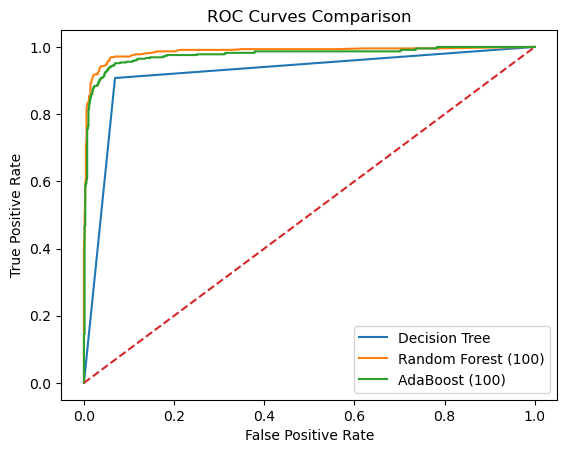

In [27]:
plt.figure()

plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest (100)")
plt.plot(fpr_ada, tpr_ada, label="AdaBoost (100)")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()

plt.show()